<a href="https://colab.research.google.com/github/sachini9-git/northstar-databases-analytics/blob/main/notebooks/01_sql_r_sqldf_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Step 1: Install and Load R Packages
# ============================================================
# Purpose:
# Load the R packages required for SQL in R, data manipulation,
# and visualisation.
#
# sqldf is used because it allows SQL queries to be written
# directly on R data frames, which matches the module approach.
# ============================================================

system("apt-get update -qq")
system("apt-get install -y -qq r-cran-sqldf r-cran-dplyr r-cran-ggplot2 r-cran-readr r-cran-lubridate")

library(sqldf)
library(dplyr)
library(ggplot2)
library(readr)
library(lubridate)

print("R packages loaded successfully: sqldf, dplyr, ggplot2, readr, lubridate.")

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




[1] "R packages loaded successfully: sqldf, dplyr, ggplot2, readr, lubridate."


In [2]:
# ============================================================
# Step 2: Import NorthStar Datasets from GitHub
# ============================================================
# Purpose:
# Load all raw NorthStar CSV files directly from the GitHub
# repository to make the workflow reproducible in Google Colab.
# ============================================================

base_url <- "https://raw.githubusercontent.com/sachini9-git/northstar-databases-analytics/main/data/raw"

customers <- read_csv(paste0(base_url, "/customers.csv"), show_col_types = FALSE)
orders <- read_csv(paste0(base_url, "/orders.csv"), show_col_types = FALSE)
deliveries <- read_csv(paste0(base_url, "/deliveries.csv"), show_col_types = FALSE)
drivers <- read_csv(paste0(base_url, "/drivers.csv"), show_col_types = FALSE)
vehicles <- read_csv(paste0(base_url, "/vehicles.csv"), show_col_types = FALSE)
hubs <- read_csv(paste0(base_url, "/hubs.csv"), show_col_types = FALSE)
incidents <- read_csv(paste0(base_url, "/incidents.csv"), show_col_types = FALSE)
complaints <- read_csv(paste0(base_url, "/complaints.csv"), show_col_types = FALSE)
app_events <- read_csv(paste0(base_url, "/app_events.csv"), show_col_types = FALSE)
data_dictionary <- read_csv(paste0(base_url, "/data_dictionary.csv"), show_col_types = FALSE)

dataset_summary <- data.frame(
  Dataset = c("customers", "orders", "deliveries", "drivers", "vehicles", "hubs", "incidents", "complaints", "app_events", "data_dictionary"),
  Records = c(nrow(customers), nrow(orders), nrow(deliveries), nrow(drivers), nrow(vehicles), nrow(hubs), nrow(incidents), nrow(complaints), nrow(app_events), nrow(data_dictionary)),
  Columns = c(ncol(customers), ncol(orders), ncol(deliveries), ncol(drivers), ncol(vehicles), ncol(hubs), ncol(incidents), ncol(complaints), ncol(app_events), ncol(data_dictionary))
)

print(dataset_summary)

           Dataset Records Columns
1        customers     650       9
2           orders    1250      11
3       deliveries     950      13
4          drivers     170       8
5         vehicles     120       8
6             hubs       8       5
7        incidents     280       7
8       complaints     320      10
9       app_events     640      10
10 data_dictionary       9       3


In [3]:
# ============================================================
# Step 3A: Create a Clear Table Output Function
# ============================================================
# Purpose:
# Plain R console output is difficult to read in screenshots.
# This function creates clean HTML-style tables for the report.
# ============================================================

if (!require(IRdisplay)) {
  install.packages("IRdisplay", repos = "https://cran.r-project.org")
  library(IRdisplay)
}

escape_html <- function(x) {
  x <- as.character(x)
  x <- gsub("&", "&amp;", x, fixed = TRUE)
  x <- gsub("<", "&lt;", x, fixed = TRUE)
  x <- gsub(">", "&gt;", x, fixed = TRUE)
  return(x)
}

nice_table <- function(df, title = "Output Table", max_rows = 20) {
  df <- as.data.frame(df)

  if (nrow(df) > max_rows) {
    df_display <- head(df, max_rows)
    note <- paste0(
      "<p style='font-size:13px;color:#333;'>Showing first ",
      max_rows, " rows from ", nrow(df), " rows.</p>"
    )
  } else {
    df_display <- df
    note <- ""
  }

  header_html <- paste0(
    "<tr>",
    paste0(
      "<th style='background-color:#1F4E79;color:white;border:1px solid #BFBFBF;padding:9px;text-align:left;font-weight:bold;'>",
      escape_html(names(df_display)),
      "</th>",
      collapse = ""
    ),
    "</tr>"
  )

  row_html <- apply(df_display, 1, function(row) {
    paste0(
      "<tr>",
      paste0(
        "<td style='color:black;border:1px solid #D9D9D9;padding:8px;background-color:white;text-align:left;'>",
        escape_html(row),
        "</td>",
        collapse = ""
      ),
      "</tr>"
    )
  })

  table_html <- paste0(
    "<div style='font-family:Arial;background-color:white;padding:12px;border-radius:8px;border:1px solid #BFBFBF;'>",
    "<h3 style='color:#1F4E79;margin-bottom:8px;'>", title, "</h3>",
    note,
    "<table style='border-collapse:collapse;width:100%;font-size:14px;color:black;'>",
    "<thead>", header_html, "</thead>",
    "<tbody>", paste0(row_html, collapse = ""), "</tbody>",
    "</table>",
    "</div>"
  )

  IRdisplay::display_html(table_html)
}

print("Clear table function is ready.")

Loading required package: IRdisplay



[1] "Clear table function is ready."


In [4]:
# ============================================================
# Step 3B: Display Dataset Summary in a Clear Table
# ============================================================
# Purpose:
# This table confirms that all NorthStar datasets were loaded
# successfully from GitHub into Google Colab.
# ============================================================

nice_table(
  dataset_summary,
  title = "NorthStar Dataset Summary Loaded from GitHub"
)

Dataset,Records,Columns
customers,650,9
orders,1250,11
deliveries,950,13
drivers,170,8
vehicles,120,8
hubs,8,5
incidents,280,7
complaints,320,10
app_events,640,10
data_dictionary,9,3


In [5]:
# ============================================================
# Step 3C: Display Data Dictionary Summary
# ============================================================
# Purpose:
# The data dictionary confirms the role of each dataset before
# performing SQL and R analysis.
# ============================================================

nice_table(
  data_dictionary,
  title = "NorthStar Data Dictionary Summary"
)

file_name,record_count,description
hubs.csv,8,Operational hubs and control points
customers.csv,650,Customer master data with engagement and loyalty metrics
drivers.csv,170,Driver workforce data with training and rating information
vehicles.csv,120,Fleet asset data including battery and maintenance indicators
orders.csv,1250,Service orders across mobility and logistics operations
deliveries.csv,950,Operational dispatch and completion outcomes
incidents.csv,280,Delivery and asset incident records
complaints.csv,320,Customer complaints and compensation handling
app_events.csv,640,Digital platform events suitable for MongoDB reshaping


In [6]:
# ============================================================
# Step 4: Data Quality Check - Zone Standardisation
# ============================================================
# Purpose:
# Check whether zone names are recorded inconsistently across
# orders, customers, drivers, vehicles, hubs, and app events.
#
# Business justification:
# Inconsistent zone labels can cause incorrect reporting, poor
# hub comparison, and unreliable location-based analysis.
# ============================================================

# Function to standardise zone values
clean_zone <- function(x) {
  x <- trimws(tolower(as.character(x)))

  x <- case_when(
    x == "north" ~ "North",
    x == "south" ~ "South",
    x == "east" ~ "East",
    x == "west" ~ "West",
    x == "central" ~ "Central",
    x == "ctr" ~ "Central",
    x == "airport" ~ "Airport",
    x == "riverside" ~ "Riverside",
    TRUE ~ tools::toTitleCase(x)
  )

  return(x)
}

# Capture values before cleaning
zone_before <- data.frame(
  Source = c("orders.pickup_zone", "orders.dropoff_zone", "hubs.zone", "customers.home_zone"),
  Zone_Values_Before = c(
    paste(unique(orders$pickup_zone), collapse = ", "),
    paste(unique(orders$dropoff_zone), collapse = ", "),
    paste(unique(hubs$zone), collapse = ", "),
    paste(unique(customers$home_zone), collapse = ", ")
  )
)

# Apply cleaning
orders$pickup_zone <- clean_zone(orders$pickup_zone)
orders$dropoff_zone <- clean_zone(orders$dropoff_zone)
customers$home_zone <- clean_zone(customers$home_zone)
drivers$base_zone <- clean_zone(drivers$base_zone)
vehicles$assigned_zone <- clean_zone(vehicles$assigned_zone)
hubs$zone <- clean_zone(hubs$zone)
app_events$zone_context <- clean_zone(app_events$zone_context)

# Capture values after cleaning
zone_after <- data.frame(
  Source = c("orders.pickup_zone", "orders.dropoff_zone", "hubs.zone", "customers.home_zone"),
  Zone_Values_After = c(
    paste(unique(orders$pickup_zone), collapse = ", "),
    paste(unique(orders$dropoff_zone), collapse = ", "),
    paste(unique(hubs$zone), collapse = ", "),
    paste(unique(customers$home_zone), collapse = ", ")
  )
)

nice_table(zone_before, title = "Zone Values Before Cleaning")
nice_table(zone_after, title = "Zone Values After Cleaning")

Source,Zone_Values_Before
orders.pickup_zone,"Airport, North, West, RiverSide, Riverside, CENTRAL, NORTH, South, WEST, East, Ctr, SOUTH, Central, AIRPORT, north, EAST"
orders.dropoff_zone,"South, AIRPORT, North, SOUTH, East, Airport, Riverside, north, Central, Ctr, CENTRAL, NORTH, RiverSide, West, EAST, WEST"
hubs.zone,"North, South, East, West, Central, Airport, Riverside"
customers.home_zone,"North, AIRPORT, East, CENTRAL, Riverside, WEST, north, South, West, Ctr, Airport, EAST, SOUTH, RiverSide, NORTH, Central"


Source,Zone_Values_After
orders.pickup_zone,"Airport, North, West, Riverside, Central, South, East"
orders.dropoff_zone,"South, Airport, North, East, Riverside, Central, West"
hubs.zone,"North, South, East, West, Central, Airport, Riverside"
customers.home_zone,"North, Airport, East, Central, Riverside, West, South"


In [7]:
# ============================================================
# Step 5: SQL Query 1 - Top 15 Longest Completed Deliveries
# ============================================================
# Purpose:
# Calculate delivery duration in minutes using dispatch_time and
# delivery_completed_at, then show the longest completed deliveries.
#
# Business justification:
# Long delivery duration can indicate route inefficiency, dispatch
# delay, route override problems, or unrealistic service promises.
# ============================================================

longest_deliveries <- sqldf("
SELECT
    delivery_id AS Delivery_ID,
    order_id AS Order_ID,
    driver_id AS Driver_ID,
    hub_id AS Hub_ID,
    delivery_status AS Delivery_Status,
    route_distance_km AS Route_Distance_KM,
    manual_route_override_count AS Manual_Route_Overrides,
    ROUND(
      (julianday(delivery_completed_at) - julianday(dispatch_time)) * 24 * 60,
      2
    ) AS Delivery_Minutes
FROM deliveries
WHERE delivery_completed_at IS NOT NULL
  AND dispatch_time IS NOT NULL
ORDER BY Delivery_Minutes DESC
LIMIT 15;
")

nice_table(
  longest_deliveries,
  title = "SQL Query 1: Top 15 Longest Completed Deliveries"
)

Delivery_ID,Order_ID,Driver_ID,Hub_ID,Delivery_Status,Route_Distance_KM,Manual_Route_Overrides,Delivery_Minutes
DL00001,O00938,D004,H05,Failed,17.26,1,NA
DL00002,O00004,D138,H02,OnTime,10.34,1,NA
DL00003,O00639,D006,H02,OnTime,7.92,0,NA
DL00004,O00313,D116,H02,Delayed,16.42,0,NA
DL00005,O00844,D108,H01,OnTime,14.52,1,NA
DL00006,O00029,D037,H03,Delayed,13.84,0,NA
DL00007,O00097,D151,H07,Delayed,32.72,0,NA
DL00008,O00207,D082,H03,OnTime,7.16,1,NA
DL00009,O00297,D088,H05,OnTime,40.23,1,NA
DL00010,O00836,D058,H08,Failed,9.85,1,NA


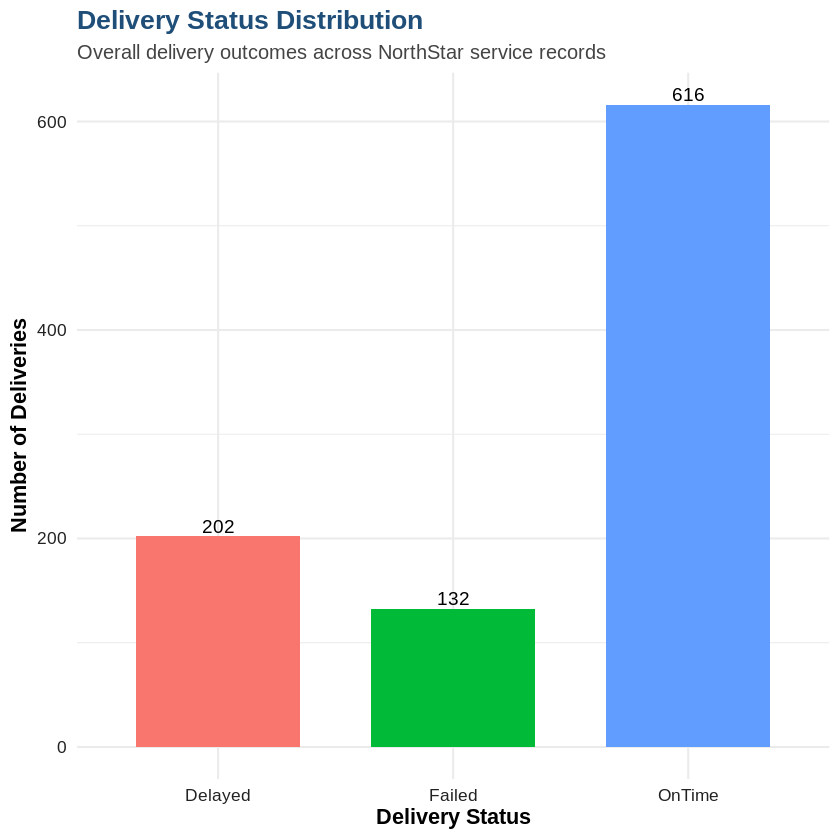

In [8]:
# ============================================================
# Step 6: R Visualisation 1 - Delivery Status Distribution
# ============================================================
# Purpose:
# Show how many deliveries fall into each delivery status category.
#
# Business justification:
# This gives a high-level view of service reliability before more
# detailed hub, route, and complaint analysis.
# ============================================================

ggplot(deliveries, aes(x = delivery_status, fill = delivery_status)) +
  geom_bar(width = 0.7, show.legend = FALSE) +
  geom_text(
    stat = "count",
    aes(label = after_stat(count)),
    vjust = -0.3,
    size = 4
  ) +
  labs(
    title = "Delivery Status Distribution",
    subtitle = "Overall delivery outcomes across NorthStar service records",
    x = "Delivery Status",
    y = "Number of Deliveries"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16, color = "#1F4E79"),
    plot.subtitle = element_text(size = 12, color = "#444444"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(color = "#222222")
  )

In [9]:
# ============================================================
# Step 5A: Prepare Timestamp Columns for SQL Duration Calculation
# ============================================================
# Purpose:
# Convert dispatch_time and delivery_completed_at into clean text
# timestamp fields so that SQLite/julianday can calculate duration.
# ============================================================

deliveries_sql <- deliveries %>%
  mutate(
    dispatch_time_clean = format(as.POSIXct(dispatch_time, tz = "UTC"), "%Y-%m-%d %H:%M:%S"),
    completed_time_clean = format(as.POSIXct(delivery_completed_at, tz = "UTC"), "%Y-%m-%d %H:%M:%S")
  )

# Check prepared timestamp columns
nice_table(
  head(deliveries_sql[, c("delivery_id", "dispatch_time", "delivery_completed_at", "dispatch_time_clean", "completed_time_clean")], 10),
  title = "Prepared Timestamp Columns for SQL Duration Calculation"
)

delivery_id,dispatch_time,delivery_completed_at,dispatch_time_clean,completed_time_clean
DL00001,2024-06-18 10:57:00,2024-06-19 09:05:59,2024-06-18 10:57:00,2024-06-19 09:05:59
DL00002,2025-01-11 18:45:00,2025-01-11 17:39:00,2025-01-11 18:45:00,2025-01-11 17:39:00
DL00003,2025-06-02 20:39:00,2025-06-02 21:45:32,2025-06-02 20:39:00,2025-06-02 21:45:32
DL00004,2024-03-08 23:31:00,2024-03-09 23:30:08,2024-03-08 23:31:00,2024-03-09 23:30:08
DL00005,2025-09-21 11:43:00,2025-09-21 15:45:34,2025-09-21 11:43:00,2025-09-21 15:45:34
DL00006,2024-09-11 12:40:00,2024-09-12 17:11:52,2024-09-11 12:40:00,2024-09-12 17:11:52
DL00007,2024-01-09 13:41:00,2024-01-10 23:39:11,2024-01-09 13:41:00,2024-01-10 23:39:11
DL00008,2024-08-22 21:34:00,2024-08-22 23:22:21,2024-08-22 21:34:00,2024-08-22 23:22:21
DL00009,2024-04-12 21:33:00,2024-04-13 01:18:52,2024-04-12 21:33:00,2024-04-13 01:18:52
DL00010,2025-09-22 19:09:00,2025-09-23 01:15:29,2025-09-22 19:09:00,2025-09-23 01:15:29


In [10]:
# ============================================================
# Step 5B: SQL Query 1 - Top 15 Longest Completed Deliveries
# ============================================================
# Purpose:
# Calculate delivery duration in minutes using cleaned timestamp
# columns and identify the longest completed deliveries.
#
# Business justification:
# Long delivery duration can indicate route inefficiency, dispatch
# delay, vehicle issues, or unrealistic service promises.
# ============================================================

longest_deliveries <- sqldf("
SELECT
    delivery_id AS Delivery_ID,
    order_id AS Order_ID,
    driver_id AS Driver_ID,
    hub_id AS Hub_ID,
    delivery_status AS Delivery_Status,
    route_distance_km AS Route_Distance_KM,
    manual_route_override_count AS Manual_Route_Overrides,

    ROUND(
      (julianday(completed_time_clean) - julianday(dispatch_time_clean)) * 24 * 60,
      2
    ) AS Delivery_Minutes

FROM deliveries_sql
WHERE completed_time_clean IS NOT NULL
  AND dispatch_time_clean IS NOT NULL
  AND ((julianday(completed_time_clean) - julianday(dispatch_time_clean)) * 24 * 60) >= 0

ORDER BY Delivery_Minutes DESC
LIMIT 15;
")

nice_table(
  longest_deliveries,
  title = "SQL Query 1: Top 15 Longest Completed Deliveries"
)

Delivery_ID,Order_ID,Driver_ID,Hub_ID,Delivery_Status,Route_Distance_KM,Manual_Route_Overrides,Delivery_Minutes
DL00386,O00135,D144,H05,Failed,1.21,1,2607.40
DL00387,O00274,D016,H01,Failed,11.96,0,2527.58
DL00033,O00885,D041,H06,Failed,11.72,0,2450.42
DL00530,O00756,D095,H01,Failed,30.51,2,2373.93
DL00026,O00906,D092,H04,Failed,14.27,2,2312.75
DL00806,O00128,D117,H07,Delayed,40.11,2,2258.88
DL00497,O00192,D083,H08,Failed,12.14,1,2237.60
DL00472,O00042,D113,H01,Delayed,10.28,0,2226.05
DL00775,O00153,D109,H05,Delayed,3.69,0,2203.93
DL00068,O00828,D104,H08,Failed,19.75,1,2192.62


In [11]:
# ============================================================
# Step 7: SQL Query 2 - Failed Deliveries
# ============================================================
# Purpose:
# This SQL query filters the delivery records to show only failed
# deliveries with key operational details.
#
# Business justification:
# Failed deliveries directly affect customer satisfaction, complaint
# levels, compensation costs, and service reliability.
# ============================================================

failed_deliveries <- sqldf("
SELECT
    delivery_id AS Delivery_ID,
    order_id AS Order_ID,
    driver_id AS Driver_ID,
    vehicle_id AS Vehicle_ID,
    hub_id AS Hub_ID,
    delivery_status AS Delivery_Status,
    route_distance_km AS Route_Distance_KM,
    manual_route_override_count AS Manual_Route_Overrides,
    customer_rating_post_delivery AS Customer_Rating,
    fuel_or_charge_cost AS Fuel_Charge_Cost
FROM deliveries
WHERE delivery_status = 'Failed'
ORDER BY manual_route_override_count DESC, fuel_or_charge_cost DESC
LIMIT 15;
")

nice_table(
  failed_deliveries,
  title = "SQL Query 2: Failed Deliveries with Operational Details"
)

Delivery_ID,Order_ID,Driver_ID,Vehicle_ID,Hub_ID,Delivery_Status,Route_Distance_KM,Manual_Route_Overrides,Customer_Rating,Fuel_Charge_Cost
DL00935,O00211,D107,V012,H08,Failed,32.42,4,3.90,14.69
DL00384,O00618,D017,V054,H05,Failed,14.52,4,2.82,10.94
DL00377,O00510,D075,V113,H07,Failed,5.45,4,2.23,10.45
DL00119,O01011,D076,V037,H03,Failed,32.37,3,1.71,25.09
DL00515,O00619,D130,V005,H04,Failed,17.55,3,3.24,21.00
DL00012,O01207,D051,V017,H05,Failed,16.96,3,NA,16.98
DL00041,O00750,D100,V057,H08,Failed,15.88,3,2.94,13.19
DL00731,O00386,D158,V042,H05,Failed,18.68,3,3.05,12.76
DL00778,O00965,D143,V005,H08,Failed,18.34,3,2.96,12.70
DL00505,O00833,D170,V017,H08,Failed,12.00,3,2.71,12.22


In [12]:
# ============================================================
# Step 8: SQL Query 3 - Hub Performance Analysis
# ============================================================
# Purpose:
# This SQL query joins deliveries and hubs to calculate total
# deliveries, failed deliveries, delayed deliveries, failure rate,
# and delay rate for each hub.
#
# Business justification:
# This helps NorthStar identify underperforming hubs where service
# failures may be linked to local dispatch, routing, hub capacity,
# driver availability, or vehicle readiness problems.
# ============================================================

hub_performance <- sqldf("
SELECT
    h.zone AS Zone,
    h.hub_name AS Hub,
    COUNT(d.delivery_id) AS Total_Deliveries,

    SUM(CASE
        WHEN d.delivery_status = 'Failed' THEN 1
        ELSE 0
    END) AS Failed_Deliveries,

    SUM(CASE
        WHEN d.delivery_status = 'Delayed' THEN 1
        ELSE 0
    END) AS Delayed_Deliveries,

    ROUND(
        100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
        / COUNT(d.delivery_id),
        2
    ) AS Failure_Rate_Percent,

    ROUND(
        100.0 * SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END)
        / COUNT(d.delivery_id),
        2
    ) AS Delay_Rate_Percent

FROM deliveries d
JOIN hubs h
    ON d.hub_id = h.hub_id

GROUP BY h.zone, h.hub_name
ORDER BY Failure_Rate_Percent DESC, Delay_Rate_Percent DESC;
")

nice_table(
  hub_performance,
  title = "SQL Query 3: Hub Failure and Delay Performance"
)

Zone,Hub,Total_Deliveries,Failed_Deliveries,Delayed_Deliveries,Failure_Rate_Percent,Delay_Rate_Percent
Central,Midtown Relay,128,26,22,20.31,17.19
Central,Central Core,115,23,25,20.00,21.74
Airport,Airport Hub,104,15,27,14.42,25.96
West,West Gate,127,16,28,12.60,22.05
North,North Exchange,136,17,26,12.50,19.12
Riverside,Riverside Hub,115,14,25,12.17,21.74
South,South Link,106,10,26,9.43,24.53
East,East Dock,119,11,23,9.24,19.33


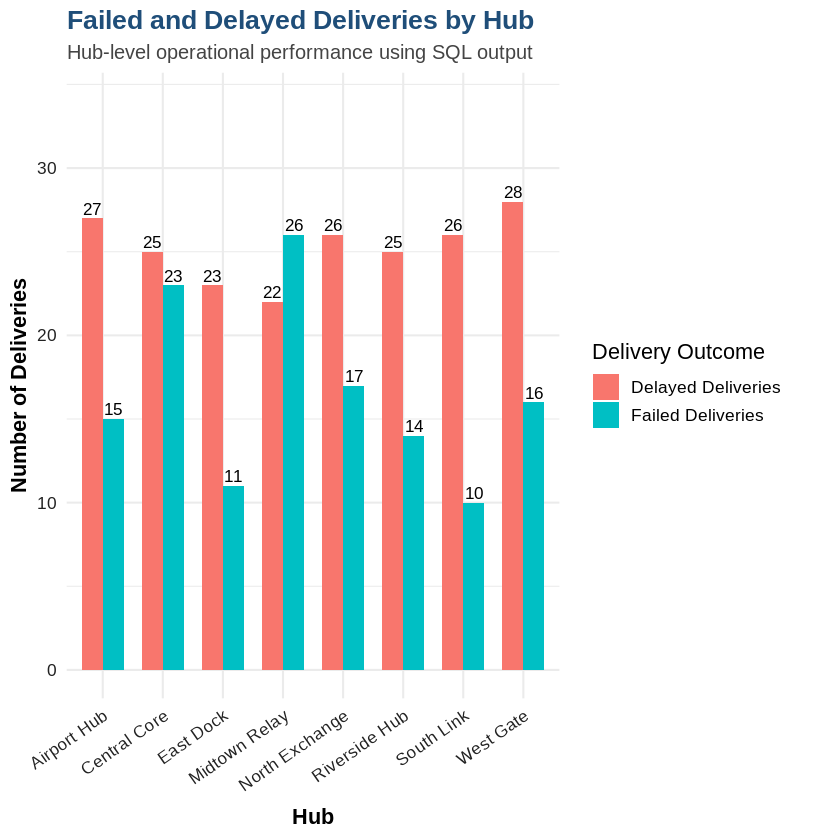

In [13]:
# ============================================================
# Step 9: R Visualisation 2 - Failed and Delayed Deliveries by Hub
# ============================================================
# Purpose:
# This grouped bar chart compares failed and delayed deliveries
# across each NorthStar hub.
#
# Business justification:
# This helps identify which hubs have higher operational reliability
# problems. Failed and delayed deliveries are shown separately so that
# management can distinguish between complete service breakdowns and
# slower service performance.
# ============================================================

# Prepare data for grouped bar chart
hub_status_chart <- data.frame(
  Hub = rep(hub_performance$Hub, 2),
  Status = c(
    rep("Failed Deliveries", nrow(hub_performance)),
    rep("Delayed Deliveries", nrow(hub_performance))
  ),
  Count = c(
    hub_performance$Failed_Deliveries,
    hub_performance$Delayed_Deliveries
  )
)

# Vertical grouped bar chart
ggplot(
  hub_status_chart,
  aes(
    x = Hub,
    y = Count,
    fill = Status
  )
) +
  geom_col(position = "dodge", width = 0.7) +
  geom_text(
    aes(label = Count),
    position = position_dodge(width = 0.7),
    vjust = -0.3,
    size = 3.6
  ) +
  labs(
    title = "Failed and Delayed Deliveries by Hub",
    subtitle = "Hub-level operational performance using SQL output",
    x = "Hub",
    y = "Number of Deliveries",
    fill = "Delivery Outcome"
  ) +
  ylim(0, max(hub_status_chart$Count) + 6) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16, color = "#1F4E79"),
    plot.subtitle = element_text(size = 12, color = "#444444"),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 35, hjust = 1, color = "#222222"),
    axis.text.y = element_text(color = "#222222"),
    legend.position = "right"
  )

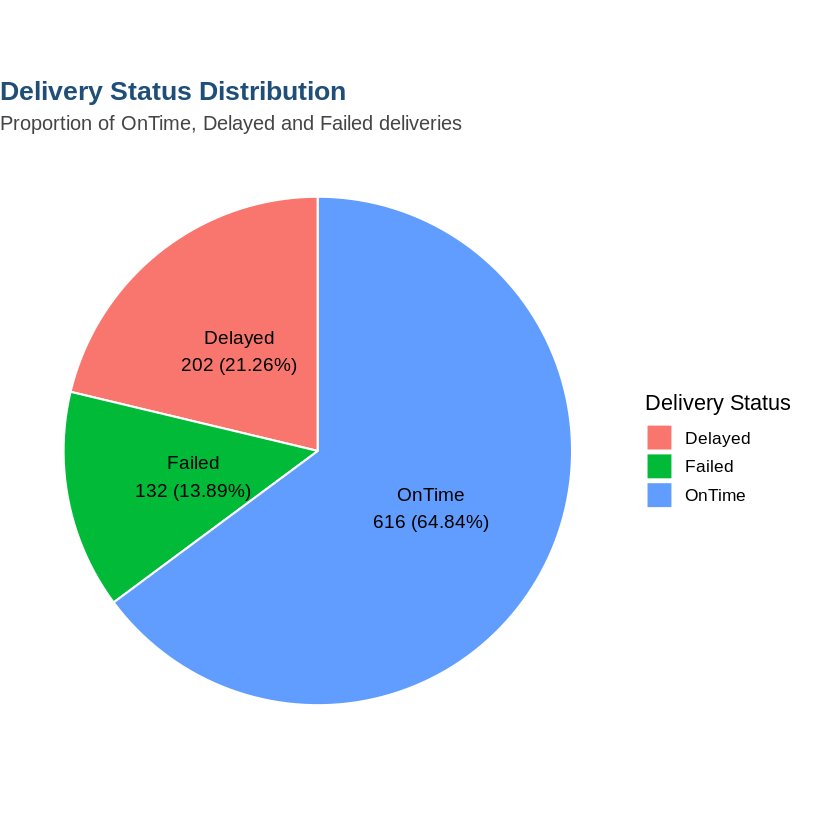

In [14]:
# ============================================================
# Step 10: R Visualisation 3 - Delivery Status Pie Chart
# ============================================================
# Purpose:
# This pie chart shows the proportion of delivery outcomes:
# OnTime, Delayed, and Failed.
#
# Business justification:
# This gives NorthStar management a quick view of overall service
# reliability and shows how much of the operation is affected by
# delays and failures.
# ============================================================

delivery_status_summary <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(Count = n()) %>%
  mutate(
    Percentage = round(100 * Count / sum(Count), 2),
    Label = paste0(delivery_status, "\n", Count, " (", Percentage, "%)")
  )

ggplot(
  delivery_status_summary,
  aes(
    x = "",
    y = Count,
    fill = delivery_status
  )
) +
  geom_col(width = 1, color = "white") +
  coord_polar(theta = "y") +
  geom_text(
    aes(label = Label),
    position = position_stack(vjust = 0.5),
    size = 4
  ) +
  labs(
    title = "Delivery Status Distribution",
    subtitle = "Proportion of OnTime, Delayed and Failed deliveries",
    fill = "Delivery Status"
  ) +
  theme_void(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16, color = "#1F4E79"),
    plot.subtitle = element_text(size = 12, color = "#444444"),
    legend.position = "right"
  )

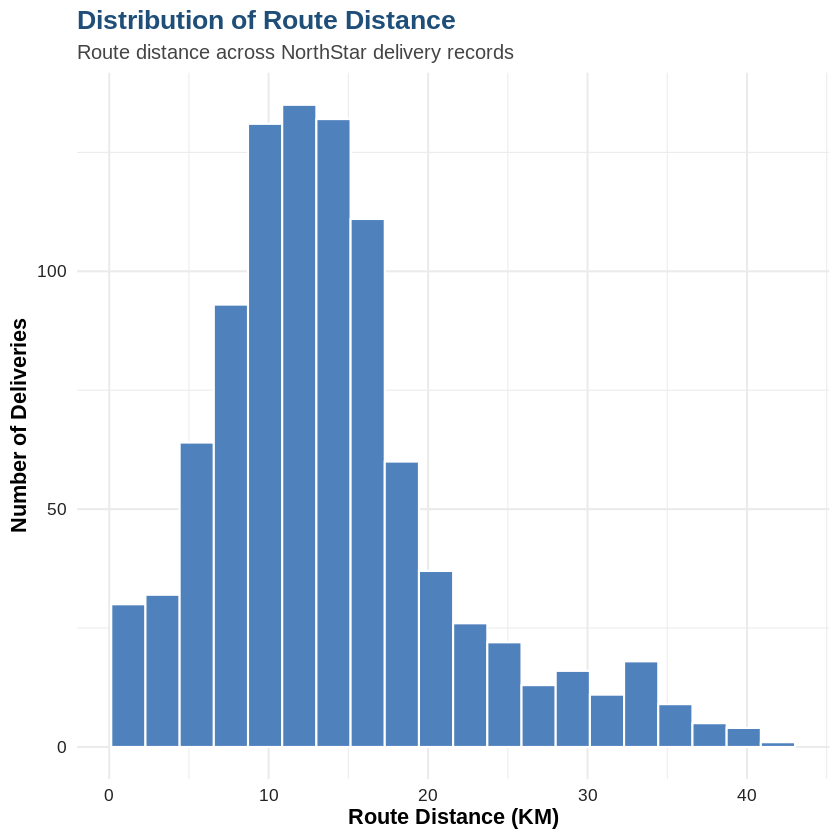

In [15]:
# ============================================================
# Step 11: R Visualisation 4 - Route Distance Histogram
# ============================================================
# Purpose:
# This histogram shows the distribution of route distances across
# delivery records.
#
# Business justification:
# Route distance affects delivery planning, driver workload,
# fuel/charge cost, and probability of delay. This helps NorthStar
# understand whether longer or unusual routes may create operational
# pressure.
# ============================================================

ggplot(
  deliveries,
  aes(x = route_distance_km)
) +
  geom_histogram(
    bins = 20,
    fill = "#4F81BD",
    color = "white"
  ) +
  labs(
    title = "Distribution of Route Distance",
    subtitle = "Route distance across NorthStar delivery records",
    x = "Route Distance (KM)",
    y = "Number of Deliveries"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16, color = "#1F4E79"),
    plot.subtitle = element_text(size = 12, color = "#444444"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(color = "#222222")
  )

In [16]:
# ============================================================
# Step 12: SQL Query 4 - Route Override Pressure by Delivery Status
# ============================================================
# Purpose:
# This SQL query groups deliveries by status and calculates average
# manual route overrides, average route distance, customer rating,
# and fuel/charge cost.
#
# Business justification:
# The case study highlights manual route overrides as a concern.
# This query tests whether route changes are higher in failed or
# delayed deliveries.
# ============================================================

route_override_status <- sqldf("
SELECT
    delivery_status AS Delivery_Status,
    COUNT(delivery_id) AS Total_Deliveries,
    ROUND(AVG(manual_route_override_count), 2) AS Avg_Manual_Overrides,
    ROUND(AVG(route_distance_km), 2) AS Avg_Route_Distance_KM,
    ROUND(AVG(customer_rating_post_delivery), 2) AS Avg_Customer_Rating,
    ROUND(AVG(fuel_or_charge_cost), 2) AS Avg_Fuel_Charge_Cost
FROM deliveries
GROUP BY delivery_status
ORDER BY Avg_Manual_Overrides DESC;
")

nice_table(
  route_override_status,
  title = "SQL Query 4: Route Override Pressure by Delivery Status"
)

Delivery_Status,Total_Deliveries,Avg_Manual_Overrides,Avg_Route_Distance_KM,Avg_Customer_Rating,Avg_Fuel_Charge_Cost
Delayed,202,1.07,14.67,3.11,13.14
Failed,132,1.04,13.37,3.05,13.15
OnTime,616,0.92,13.78,4.28,12.68


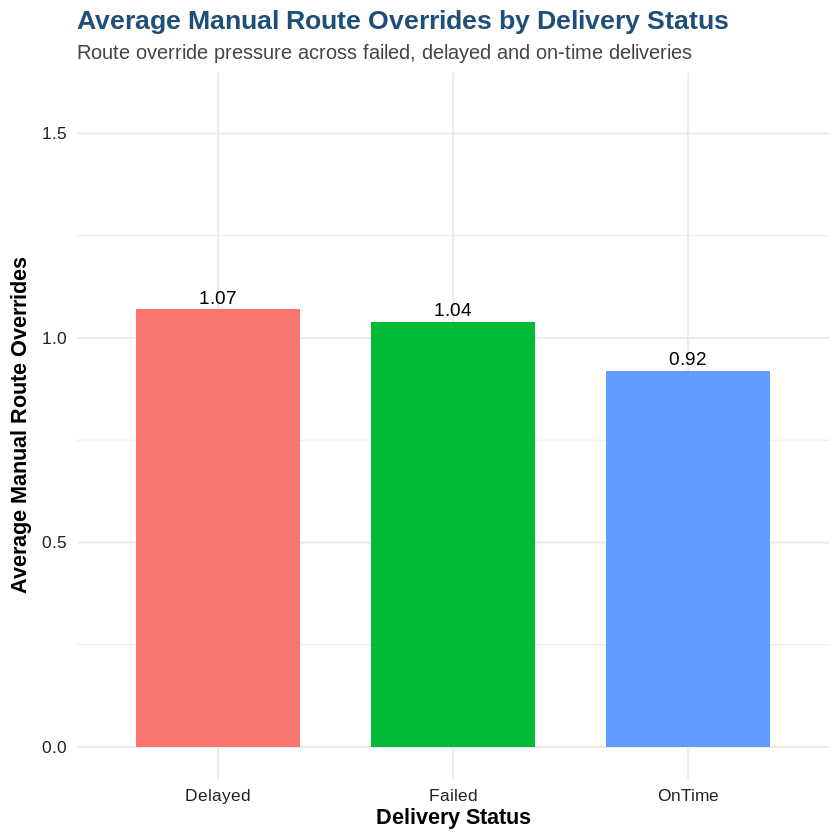

In [17]:
# ============================================================
# Step 13: R Visualisation 5 - Route Override Pressure
# ============================================================
# Purpose:
# Visualise average manual route overrides by delivery status.
#
# Business justification:
# This helps test whether manual route changes are linked with
# delayed or failed service outcomes.
# ============================================================

ggplot(
  route_override_status,
  aes(
    x = Delivery_Status,
    y = Avg_Manual_Overrides,
    fill = Delivery_Status
  )
) +
  geom_col(width = 0.7, show.legend = FALSE) +
  geom_text(
    aes(label = Avg_Manual_Overrides),
    vjust = -0.4,
    size = 4
  ) +
  labs(
    title = "Average Manual Route Overrides by Delivery Status",
    subtitle = "Route override pressure across failed, delayed and on-time deliveries",
    x = "Delivery Status",
    y = "Average Manual Route Overrides"
  ) +
  ylim(0, max(route_override_status$Avg_Manual_Overrides) + 0.5) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16, color = "#1F4E79"),
    plot.subtitle = element_text(size = 12, color = "#444444"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(color = "#222222")
  )

In [18]:
# ============================================================
# Step 14: dplyr Transformation - Delivery Duration Summary
# ============================================================
# Purpose:
# Use dplyr to calculate delivery duration and summarise average
# duration by delivery status.
#
# Business justification:
# This shows whether failed or delayed deliveries have longer
# recorded service durations than on-time deliveries.
# ============================================================

delivery_duration_summary <- deliveries_sql %>%
  mutate(
    Delivery_Minutes = as.numeric(
      difftime(
        as.POSIXct(completed_time_clean, tz = "UTC"),
        as.POSIXct(dispatch_time_clean, tz = "UTC"),
        units = "mins"
      )
    )
  ) %>%
  filter(!is.na(Delivery_Minutes), Delivery_Minutes >= 0) %>%
  group_by(delivery_status) %>%
  summarise(
    Total_Deliveries = n(),
    Avg_Delivery_Minutes = round(mean(Delivery_Minutes), 2),
    Median_Delivery_Minutes = round(median(Delivery_Minutes), 2),
    Max_Delivery_Minutes = round(max(Delivery_Minutes), 2)
  ) %>%
  arrange(desc(Avg_Delivery_Minutes))

nice_table(
  delivery_duration_summary,
  title = "dplyr Transformation: Delivery Duration Summary by Status"
)

delivery_status,Total_Deliveries,Avg_Delivery_Minutes,Median_Delivery_Minutes,Max_Delivery_Minutes
Failed,129,1066.94,998.18,2607.40
Delayed,198,810.59,746.94,2258.88
OnTime,540,441.78,263.50,1534.57


In [19]:
# ============================================================
# Step 15: SQL Query 5 - Average Fuel/Charge Cost by Delivery Status
# ============================================================
# Purpose:
# Calculate the average fuel/charge cost for each delivery status.
#
# Business justification:
# Failed and delayed deliveries may create cost inefficiency through
# wasted vehicle usage, longer routes, compensation, and repeated work.
# ============================================================

cost_by_status <- sqldf("
SELECT
    delivery_status AS Delivery_Status,
    COUNT(delivery_id) AS Total_Deliveries,
    ROUND(AVG(fuel_or_charge_cost), 2) AS Avg_Fuel_Charge_Cost,
    ROUND(MIN(fuel_or_charge_cost), 2) AS Min_Fuel_Charge_Cost,
    ROUND(MAX(fuel_or_charge_cost), 2) AS Max_Fuel_Charge_Cost
FROM deliveries
GROUP BY delivery_status
ORDER BY Avg_Fuel_Charge_Cost DESC;
")

nice_table(
  cost_by_status,
  title = "SQL Query 5: Average Fuel/Charge Cost by Delivery Status"
)

Delivery_Status,Total_Deliveries,Avg_Fuel_Charge_Cost,Min_Fuel_Charge_Cost,Max_Fuel_Charge_Cost
Failed,132,13.15,3.56,25.46
Delayed,202,13.14,2.50,24.54
OnTime,616,12.68,2.50,29.43


In [20]:
# ============================================================
# Step 16: SQL Query 6 - Driver Performance and Cost Analysis
# ============================================================
# Purpose:
# Join deliveries with drivers to compare driver-level delivery
# volume, failures, average rating, and average cost.
#
# Business justification:
# This helps NorthStar identify whether delivery issues are linked
# to driver experience, ratings, or route execution patterns.
# ============================================================

driver_performance <- sqldf("
SELECT
    dr.driver_id AS Driver_ID,
    dr.employment_type AS Employment_Type,
    dr.base_zone AS Base_Zone,
    COUNT(d.delivery_id) AS Total_Deliveries,

    SUM(CASE
        WHEN d.delivery_status = 'Failed' THEN 1
        ELSE 0
    END) AS Failed_Deliveries,

    ROUND(AVG(d.customer_rating_post_delivery), 2) AS Avg_Customer_Rating,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS Avg_Fuel_Charge_Cost,
    ROUND(AVG(d.manual_route_override_count), 2) AS Avg_Manual_Overrides

FROM deliveries d
JOIN drivers dr
    ON d.driver_id = dr.driver_id

GROUP BY dr.driver_id, dr.employment_type, dr.base_zone
HAVING COUNT(d.delivery_id) >= 3
ORDER BY Failed_Deliveries DESC, Avg_Customer_Rating ASC
LIMIT 15;
")

nice_table(
  driver_performance,
  title = "SQL Query 6: Driver Performance and Cost Analysis"
)

Driver_ID,Employment_Type,Base_Zone,Total_Deliveries,Failed_Deliveries,Avg_Customer_Rating,Avg_Fuel_Charge_Cost,Avg_Manual_Overrides
D133,Contract,South,12,4,3.42,11.14,0.92
D024,PartTime,Riverside,8,4,3.44,12.81,1.13
D104,FullTime,West,7,4,3.93,13.63,1.71
D092,FullTime,East,5,3,3.38,10.88,0.40
D004,PartTime,Airport,9,3,3.51,12.91,0.78
D131,FullTime,South,9,3,3.66,13.16,1.67
D055,FullTime,Central,10,3,3.81,11.71,1.10
D083,FullTime,North,9,3,3.91,12.77,1.00
D010,FullTime,West,7,3,4.15,10.72,0.86
D108,FullTime,South,11,3,4.41,13.92,1.36


In [21]:
simulated_insert <- sqldf("
SELECT * FROM (
    SELECT
        delivery_id AS Delivery_ID,
        order_id AS Order_ID,
        delivery_status AS Delivery_Status,
        route_distance_km AS Route_Distance_KM,
        manual_route_override_count AS Manual_Route_Overrides,
        customer_rating_post_delivery AS Customer_Rating
    FROM deliveries
    LIMIT 5
)
UNION ALL
SELECT
    'DLTEST001' AS Delivery_ID,
    'OTEST001' AS Order_ID,
    'Delayed' AS Delivery_Status,
    18.75 AS Route_Distance_KM,
    2 AS Manual_Route_Overrides,
    3.20 AS Customer_Rating;
")

nice_table(
  simulated_insert,
  title = "SQL Simulation: Insert New Delivery Record"
)

Delivery_ID,Order_ID,Delivery_Status,Route_Distance_KM,Manual_Route_Overrides,Customer_Rating
DL00001,O00938,Failed,17.26,1,3.07
DL00002,O00004,OnTime,10.34,1,5.00
DL00003,O00639,OnTime,7.92,0,4.98
DL00004,O00313,Delayed,16.42,0,4.18
DL00005,O00844,OnTime,14.52,1,4.18
DLTEST001,OTEST001,Delayed,18.75,2,3.20


In [22]:
# ============================================================
# Step 18: Simulated SQL Update Operation
# ============================================================
# Purpose:
# Demonstrate how delivery status could be updated using a SQL
# CASE statement.
#
# Business justification:
# This reflects how NorthStar could update a delivery record after
# investigation, for example when a failed delivery is reviewed.
# ============================================================

simulated_update <- sqldf("
SELECT
    delivery_id AS Delivery_ID,
    order_id AS Order_ID,
    delivery_status AS Original_Status,

    CASE
        WHEN delivery_id = 'DL00001' THEN 'Reviewed'
        ELSE delivery_status
    END AS Updated_Status,

    route_distance_km AS Route_Distance_KM,
    manual_route_override_count AS Manual_Route_Overrides

FROM deliveries
WHERE delivery_id IN ('DL00001', 'DL00002', 'DL00003', 'DL00004', 'DL00005');
")

nice_table(
  simulated_update,
  title = "SQL Simulation: Update Delivery Status Using CASE"
)

Delivery_ID,Order_ID,Original_Status,Updated_Status,Route_Distance_KM,Manual_Route_Overrides
DL00001,O00938,Failed,Reviewed,17.26,1
DL00002,O00004,OnTime,OnTime,10.34,1
DL00003,O00639,OnTime,OnTime,7.92,0
DL00004,O00313,Delayed,Delayed,16.42,0
DL00005,O00844,OnTime,OnTime,14.52,1


In [23]:
# ============================================================
# Step 19: Simulated SQL Delete Operation
# ============================================================
# Purpose:
# Demonstrate how a test or invalid record could be removed using
# SQL filtering logic.
#
# Business justification:
# This shows how NorthStar can remove temporary, duplicate, or test
# records during data cleaning without affecting the original dataset.
# ============================================================

simulated_delete <- sqldf("
SELECT
    delivery_id AS Delivery_ID,
    order_id AS Order_ID,
    delivery_status AS Delivery_Status,
    route_distance_km AS Route_Distance_KM
FROM deliveries
WHERE delivery_id NOT IN ('DL00001')
LIMIT 10;
")

nice_table(
  simulated_delete,
  title = "SQL Simulation: Delete/Remove One Delivery Record"
)

Delivery_ID,Order_ID,Delivery_Status,Route_Distance_KM
DL00002,O00004,OnTime,10.34
DL00003,O00639,OnTime,7.92
DL00004,O00313,Delayed,16.42
DL00005,O00844,OnTime,14.52
DL00006,O00029,Delayed,13.84
DL00007,O00097,Delayed,32.72
DL00008,O00207,OnTime,7.16
DL00009,O00297,OnTime,40.23
DL00010,O00836,Failed,9.85
DL00011,O00202,OnTime,13.85


In [24]:
# ============================================================
# Step 20: SQL Query 7 - Complaints by Service Type
# ============================================================
# Purpose:
# Join orders and complaints to calculate complaint volume and
# average compensation by service type.
#
# Business justification:
# This helps NorthStar identify which services create the highest
# complaint pressure and compensation exposure.
# ============================================================

complaints_by_service <- sqldf("
SELECT
    o.service_type AS Service_Type,
    COUNT(DISTINCT o.order_id) AS Total_Orders,
    COUNT(c.complaint_id) AS Total_Complaints,
    ROUND(100.0 * COUNT(c.complaint_id) / COUNT(DISTINCT o.order_id), 2) AS Complaint_Rate_Percent,
    ROUND(AVG(c.compensation_amount), 2) AS Avg_Compensation,
    ROUND(SUM(c.compensation_amount), 2) AS Total_Compensation
FROM orders o
LEFT JOIN complaints c
    ON o.order_id = c.order_id
GROUP BY o.service_type
ORDER BY Complaint_Rate_Percent DESC;
")

nice_table(
  complaints_by_service,
  title = "SQL Query 7: Complaints and Compensation by Service Type"
)

Service_Type,Total_Orders,Total_Complaints,Complaint_Rate_Percent,Avg_Compensation,Total_Compensation
Retail,297,83,27.95,19.05,1486.14
Medical,139,37,26.62,20.56,740.01
Parcel,308,77,25.00,20.61,1463.65
Passenger,341,84,24.63,20.72,1657.53
Business,165,39,23.64,20.79,810.86


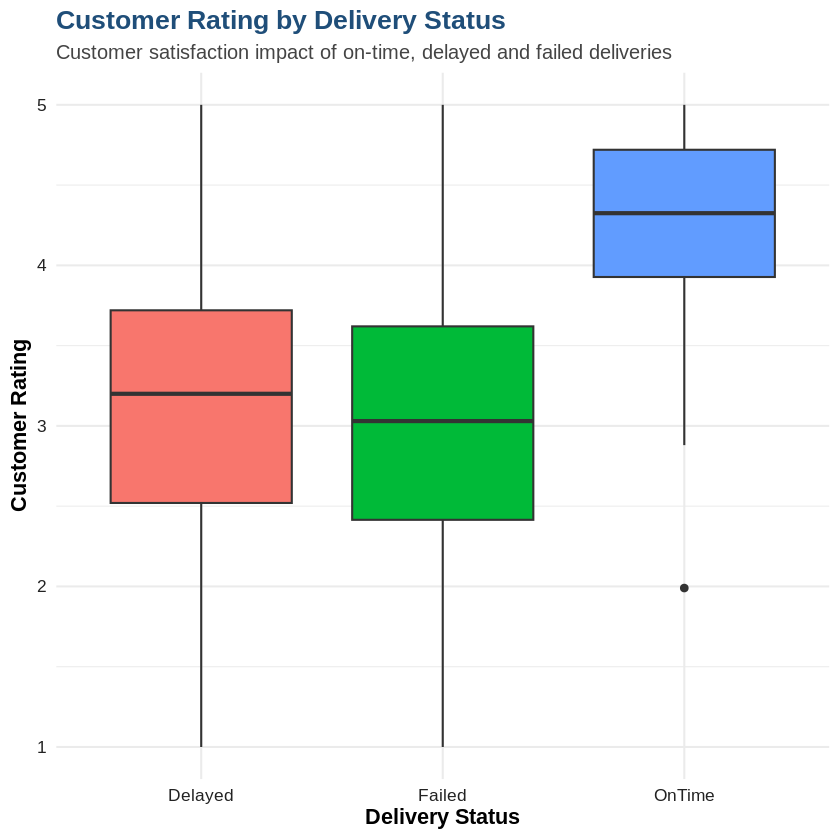

In [25]:
# ============================================================
# Step 21: R Visualisation 6 - Customer Rating by Delivery Status
# ============================================================
# Purpose:
# Compare customer ratings across OnTime, Delayed and Failed
# deliveries using a boxplot.
#
# Business justification:
# This shows whether poor delivery outcomes are linked to lower
# customer satisfaction.
# ============================================================

rating_clean <- deliveries %>%
  filter(!is.na(customer_rating_post_delivery))

ggplot(
  rating_clean,
  aes(
    x = delivery_status,
    y = customer_rating_post_delivery,
    fill = delivery_status
  )
) +
  geom_boxplot(show.legend = FALSE) +
  labs(
    title = "Customer Rating by Delivery Status",
    subtitle = "Customer satisfaction impact of on-time, delayed and failed deliveries",
    x = "Delivery Status",
    y = "Customer Rating"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16, color = "#1F4E79"),
    plot.subtitle = element_text(size = 12, color = "#444444"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(color = "#222222")
  )